In [1]:
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, 
    precision_recall_fscore_support,
    roc_curve,
    accuracy_score,
    roc_auc_score)

import statsmodels.api as sm

from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    BorderlineSMOTE)

from pygam import LinearGAM, s, f, l

from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Naive Bayes
## The Naive Solution

In [2]:
# Load the loan data and display the first 3 rows
loan_data = pd.read_csv('loan_data.csv.gz')
loan_data.head(3)

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.3932,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.5717,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.7160,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60


In [3]:
# Convert to category data types
loan_data["outcome"] = loan_data["outcome"].astype("category")
loan_data["outcome"].cat.reorder_categories(["paid off", "default"])
loan_data["purpose_"] = loan_data["purpose_"].astype("category")
loan_data["home_"] = loan_data["home_"].astype("category")
loan_data["emp_len_"] = loan_data["emp_len_"].astype("category")

# Create the X and y sets for model
predictors=["purpose_","home_","emp_len_"]
outcome = "outcome"
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
y = loan_data[outcome]

# Instantiate 1 Multinomial Naive Bayes model 
naive_model = MultinomialNB(alpha=0.1, fit_prior=True)
#naive_model = MultinomialNB(alpha=1e-10, fit_prior=False)
naive_model.fit(X,y)

# Predict the value of a new loan using row 146
new_loan = X.loc[146:146, :]
print("Predicted class=", naive_model.predict(new_loan)[0])

# Calculate the probabilities for the default/paid off classification of the loan
# and store them in a dataframe
probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns = naive_model.classes_)

# Print the probabilities
print("Predicted probabilities")
print(probabilities)

Predicted class= default
Predicted probabilities
    default  paid off
0  0.653673  0.346327


# Discriminant Analysis
## A Simple Example

In [4]:
# Load the loan data and disply the first 3 rows
loan3000 = pd.read_csv('loan3000.csv')
loan3000.head(3)

,Unnamed: 0,outcome,purpose_,dti,borrower_score,payment_inc_ratio
0,32109,paid off,debt_consolidation,21.23,0.4,5.11135
1,16982,default,credit_card,15.49,0.4,5.43165
2,25335,paid off,debt_consolidation,27.30,0.7,9.23003


In [5]:
loan3000["outcome"] = loan3000.outcome.astype('category')

# Create the X and y sets for the model
predictors = ['borrower_score','payment_inc_ratio']
outsome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

# Build an LDA model
loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


In [6]:
# Calculate the probabilities of each row using the predictor columns
# reate a dataframe based on the probabilities labeled after the classes_ of the model
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


### Figure 5.1

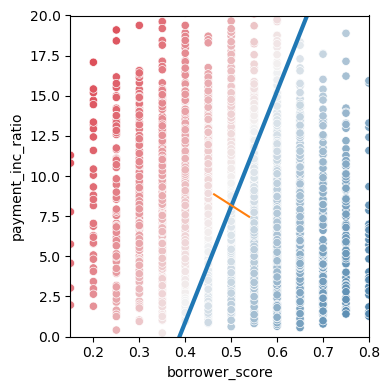

In [7]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = -loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# Payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0-intercept)/slope
x_20 = (20 - intercept)/slope

lda_df = pd.concat([loan3000, pred['default']],axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4,4))
g = sns.scatterplot(x = "borrower_score",
                    y = "payment_inc_ratio",
                    hue = "default",
                    data=lda_df,
                    palette=sns.diverging_palette(
                        240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)
ax.set_xlim(0.15, 0.8)
ax.set_ylim(0,20)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()
                    

# Logistic regression
## Logistic Response Function and Logit

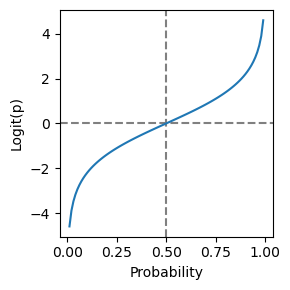

In [8]:
# Create a manual logistic regression plot
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    "p":p,
    "logit": np.log(p/(1-p)),
    "odds": p/(1-p)
})

fig, ax = plt.subplots(figsize=(3,3))
ax.axhline( 0, color = "grey", linestyle="--")
ax.axvline(0.5, color="grey", linestyle="--")
ax.plot(df["p"], df["logit"])
ax.set_xlabel("Probability")
ax.set_ylabel("Logit(p)")

plt.tight_layout()
plt.show()

## Logistic Regression and the GLM

In [9]:
# Create the X an y set for the model
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], 
                   prefix='', 
                   prefix_sep='',
                   drop_first=True,
                   dtype=int)
y = loan_data[outcome]


# Create a LogisticRegression model
logit_reg = LogisticRegression(penalty='l2',
                               C=1e42,
                               solver='liblinear')
logit_reg.fit(X,y)

# Print the intercept and classes of the model
print("intercept ", logit_reg.intercept_[0])
print('classes', logit_reg.classes_)

# Create a dataframe of the coefficients of the logistic regression model    
pd.DataFrame({"coeff": logit_reg.coef_[0]},
             index=X.columns)

intercept  -1.6378908642001215
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079739
borrower_score,4.612183
debt_consolidation,-0.249414
home_improvement,-0.407734
major_purchase,-0.229710
medical,-0.510744
other,-0.620800
small_business,-1.214936
OWN,-0.048211
RENT,-0.157288


In [10]:
# Display the categories of the loan data columns
print(loan_data["purpose_"].cat.categories)
print(loan_data["home_"].cat.categories)
print(loan_data["emp_len_"].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


In [11]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[["paid off","default"]])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2",
                                   C = 1e42,
                                   solver="liblinear")
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]}, 
             index=X.columns)

intercept  1.6378909053062045
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


In [12]:
# Create an ordinal encoder of the y target categories
# Paid off is '0' and default is '1'
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]}, 
             index=X.columns)

intercept  1.6378909053062045
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


### Predicted Values from Logistic Regression

In [13]:
# Predict the probailities of default/paid off using X 
# Create a dataframe of the prediction results
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)

# Describe the pred dataframe to get characteristics of the predictions
print(pred.describe().T)

            count      mean       std       min       25%       50%       75%  \
default   45342.0 -0.757872  0.378093 -2.769376 -0.985739 -0.697406 -0.472183   
paid off  45342.0 -0.760434  0.390456 -3.538593 -0.977207 -0.688907 -0.467069   

               max  
default  -0.029485  
paid off -0.064753  


In [14]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe().T)

            count  mean       std       min       25%       50%       75%  \
default   45342.0   0.5  0.167354  0.062701  0.373163  0.497875  0.623639   
paid off  45342.0   0.5  0.167354  0.029054  0.376361  0.502125  0.626837   

               max  
default   0.970946  
paid off  0.937299  


## Interpreting the Coefficients and Odds Ratios

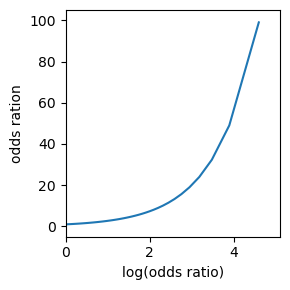

In [15]:
# Create a line plot of the manually log offs/ odds data
fig, ax = plt.subplots(figsize=(3,3))
ax.plot(df["logit"], df["odds"])
ax.set_xlabel("log(odds ratio)")
ax.set_ylabel("odds ration")
ax.set_xlim(0,5.1)
ax.set_ylim(-5,105)
plt.tight_layout()
plt.show()

## Assessing the Model

In [16]:
# Create a GLM Classification (Binomial) model of the loan data for default/paid off for y
# Display the summary results of the model
y_numbers = [1 if yi == "default" else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
                      family = sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Mon, 16 Jun 2025   Deviance:                       57515.
Time:                        01:02:04   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

In [17]:
# Create a GLM Classification (Binomial) model of the loan data
# Add splines to the X variables
    # bs(payment_inc_ratio, df=8 : Create 8 splines for payment_inc_ratio
    # bs(borrower_score, df=3)   : Create 3 splines for borrower_score
# Display the summary results of the model
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
model = smf.glm(formula=formula,
                data=loan_data,
                family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45321
Model Family:                                       Binomial   Df Model:                           20
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28731.
Date:                                       Mon, 16 Jun 2025   Deviance:                       57462.
Time:                                               01:02:05   Pearson chi2:                 4.54e+04
No. Iterations:                                            6   Pseudo R-squ. (CS):             0.1122
Covariance Type:                                   nonrobust                      

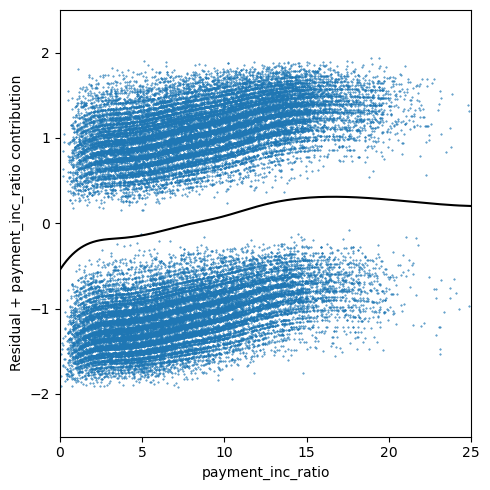

In [18]:
from statsmodels.genmod.generalized_linear_model import GLMResults

# Create a function to plot a partial residualfor the GLM
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

# Evaluating Classification Models
## Confusion Matrix

In [19]:
# Create confusion matrix for the logit regression model using predictions
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == "default"
true_y = y == "default"
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)],
                         [np.sum(false_pos), np.sum(true_neg)]],
                       index=["Y = default", "Y = paid off"],
                       columns = ["Yhat = default", "Yhat = paid off"])
print(conf_mat)

              Yhat = default  Yhat = paid off
Y = default            14337             8334
Y = paid off            8149            14522


In [20]:
# Print the confusion matrix using sklearn.metrics.confusion_matrix
print(confusion_matrix(y, logit_reg.predict(X)))

[[14337  8334]
 [ 8149 14522]]


## Precision, Recall, and Specificity

In [21]:
# Using the sklearn confusion_matrix calculate
# precision, recall, and specificity
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print("Precision", conf_mat[0,0] / sum(conf_mat[:,0]))
print("Recall", conf_mat[0,0] / sum(conf_mat[0,:]))
print("Specificity", conf_mat[1,1] / sum(conf_mat[1,:]))

Precision 0.6375967268522637
Recall 0.6323938070662961
Specificity 0.640554011733051


In [22]:
# Display the precision_recall_f1score_support from sklearn
# Would need to build labels around this for clarity
precision_recall_fscore_support(
    y, logit_reg.predict(X),
    labels=["default","paid off"])

(array([0.63759673, 0.63536927]),
 array([0.63239381, 0.64055401]),
 array([0.63498461, 0.63795111]),
 array([22671, 22671], dtype=int64))

## ROC Curve

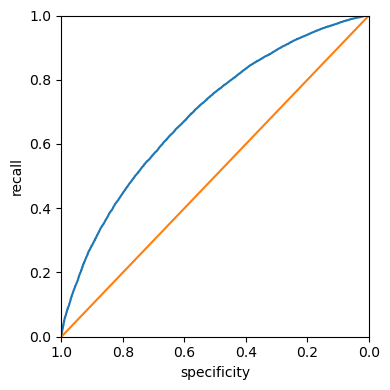

In [23]:
# Create an ROC curve based on the predicted probabilities
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0],
                                 pos_label = "default")
roc_df = pd.DataFrame({"recall": tpr, "specificity": 1-fpr})

ax = roc_df.plot(x="specificity",
                 y="recall",
                 figsize=(4,4),
                 legend=False)
ax.set_ylim(0,1)
ax.set_xlim(1,0)
ax.plot((1,0),(0,1))
ax.set_xlabel("specificity")
ax.set_ylabel("recall")

plt.tight_layout()
plt.show()

## AUC

In [24]:
# Calculate the ROC-AUC score manually
print(np.sum(roc_df.recall[:-1]*np.diff(1-roc_df.specificity)))

# Calcuate the ROC-AUC score manually
print(roc_auc_score([1 if yi=="default" else 0 for yi in y],
                    logit_reg.predict_proba(X)[:, 0]))

0.6917107174637571
0.691710795288669


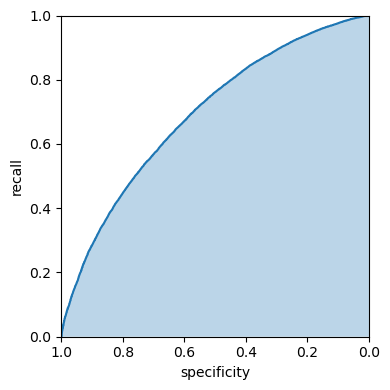

In [25]:
# PLot the ROC-AUC 
fpr, tpr, threshold = roc_curve(y,
                               logit_reg.predict_proba(X)[:,0],
                               pos_label="default")
roc_df = pd.DataFrame({"recall":tpr,
                       "specificity": 1-fpr})

ax = roc_df.plot(x="specificity",
                 y="recall",
                 figsize=(4,4),
                 legend=False)
ax.set_ylim(0,1)
ax.set_xlim(1,0)
ax.set_xlabel("specificity")
ax.set_ylabel("recall")
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)
plt.tight_layout()
plt.show()

# Strategies for Imbalanced Data
## Undersampling
> The results differ from the R version, however are equivalent to results obtained using the R code. Model based results are of similar magnitude.

In [26]:
# Load the full train set data
full_train_set = pd.read_csv("full_train_set.csv.gz")
print(full_train_set.shape)

(119987, 19)


In [27]:
# Calculate the loan default percentage
print("Percentage of loans in default: ", 100*np.mean(full_train_set["outcome"]=="default"))

Percentage of loans in default:  18.894546909248504


In [28]:
# Build a logistic regression model without balancing
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('percentage of loans predicted to default: ', 100 * np.mean(full_model.predict(X) == 'default'))

percentage of loans predicted to default:  1.0134431230049923


In [29]:
(np.mean(full_train_set.outcome == 'default') / 
 np.mean(full_model.predict(X) == 'default'))

18.64391447368421

## Oversampling and Up/Down Weighting

In [30]:
# Create logistic regression using weighting
default_wt = 1 / np.mean(full_train_set.outcome == 'default')
wt = [default_wt if outcome=='default' else 1 for outcome in full_train_set.outcome]

full_model = LogisticRegression(penalty="l2", C=1e42, solver="liblinear")
full_model.fit(X,y, sample_weight=wt)
print('percentage of loans predicted to default (weighting): ', 100 * np.mean(full_model.predict(X) == 'default'))

percentage of loans predicted to default (weighting):  61.52833223599223


## Data Generation
The package _imbalanced-learn_ provides an implementation of the _SMOTE_ and similar algorithms. 

In [31]:
# Perform oversampling using SMOTE
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('percentage of loans in default (SMOTE resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ', 
      100 * np.mean(full_model.predict(X) == 'default'))

# Perform oversampling using ADASYN
X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (ADASYN): ', 
      100 * np.mean(full_model.predict(X) == 'default'))

percentage of loans in default (SMOTE resampled):  50.0
percentage of loans predicted to default (SMOTE):  29.495695366998092
percentage of loans in default (ADASYN resampled):  48.56040383751355
percentage of loans predicted to default (ADASYN):  27.482977322543274


## Exploring the Predictions

In [32]:
# Load the load data
loan3000 = pd.read_csv("loan3000.csv")

In [33]:
# Create models for
#   DecisionTreeClassifier
#   LineaerDiscriminatAnalysis (LDA)
#   LogistiRegression
#   GAM

# Estalish the X predictors and y target outcome
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(
    random_state=1,
    criterion='entropy',
    min_impurity_decrease=0.003)
loan_tree.fit(X,y)

loan_lda=LinearDiscriminantAnalysis()
loan_lda.fit(X,y)

logit_reg = LogisticRegression(
    penalty="l2", solver="liblinear")
logit_reg.fit(X, y)

gam = LinearGAM(s(0) + s(1))
print(gam.gridsearch(X.values, [1 if yi == "default" else 0 for yi in y]))


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


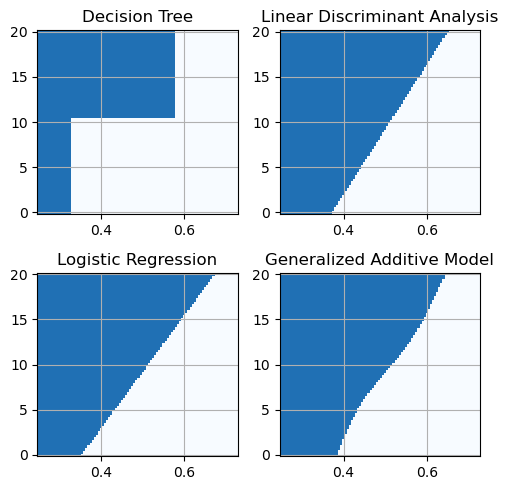

In [34]:
models = {
    'Decision Tree': loan_tree,
    'Linear Discriminant Analysis': loan_lda,
    'Logistic Regression': logit_reg,
    'Generalized Additive Model': gam,
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))

xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
X = pd.DataFrame({
    'borrower_score': xx.ravel(),
    'payment_inc_ratio': yy.ravel(),
})

boundary = {}

# Plot the decision rules for the 4 models previously built above
for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        
        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1,:] == 0] = yvalues[-1]

    c = ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

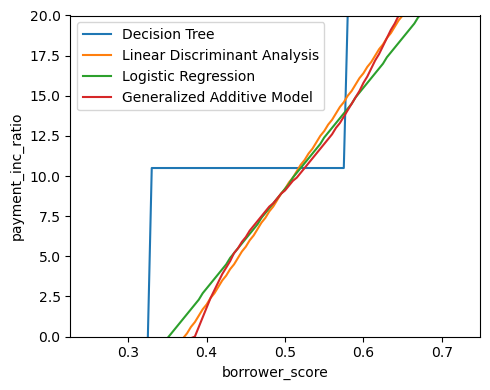

In [35]:
# Plot the decision rules for the 4 models previously built above
boundary["borrower_score"] = xvalues
boundaries = pd.DataFrame(boundary)

fig, ax = plt.subplots(figsize=(5,4))
boundaries.plot(x="borrower_score", ax=ax)
ax.set_ylabel("payment_inc_ratio")
ax.set_ylim(0,20)

plt.tight_layout()
plt.show()